# MNIST using tensorflow



In [8]:
# Import libraries
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load MNIST dataset (digits 0–9)
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

# Normalize pixel values (0–255 to 0–1)
x_train = x_train / 255.0
x_test = x_test / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# Build the model
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),  # Convert 2D image to 1D vector
    layers.Dense(128, activation='relu'),  # Hidden layer
    layers.Dense(10, activation='softmax') # Output layer (10 digits)
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [4]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [5]:
# Train the model
model.fit(x_train, y_train, epochs=5)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9263 - loss: 0.2601
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9662 - loss: 0.1137
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9760 - loss: 0.0797
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9819 - loss: 0.0590
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9857 - loss: 0.0473


In [6]:
# Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9772 - loss: 0.0711
Test accuracy: 0.9771999716758728


## Visualizing the results

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


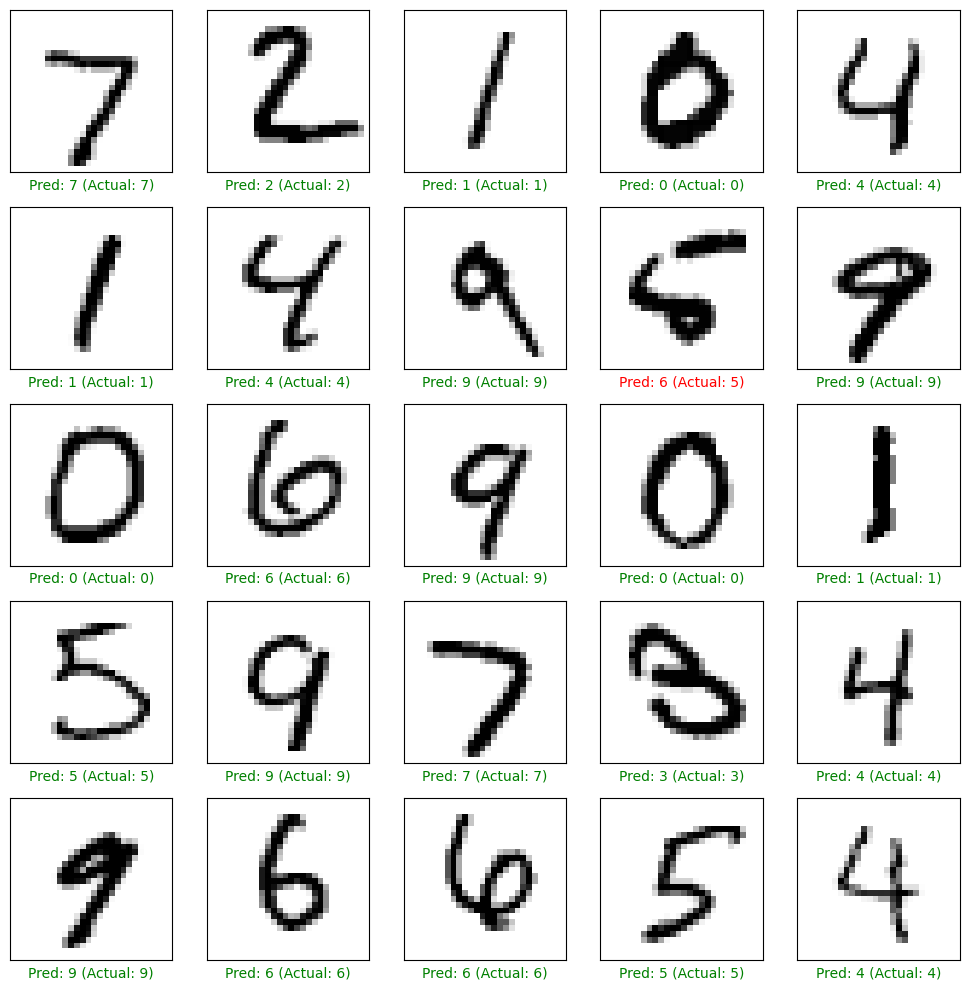

In [7]:

#Get predictions for the test set
predictions = model.predict(x_test)

#Set up a grid for plotting
plt.figure(figsize=(10, 10))

for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)

    plt.imshow(x_test[i], cmap=plt.cm.binary)

    predicted_label = np.argmax(predictions[i])
    true_label = y_test[i]
    color = 'green' if predicted_label == true_label else 'red'

    plt.xlabel(f"Pred: {predicted_label} (Actual: {true_label})", color=color)

plt.tight_layout()
plt.show()